In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.parser import parse
from numpy.linalg import lstsq
import numpy as np

In [2]:
f = "../data/demanda_utci_regions.parquet"
data = pd.read_parquet(f)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63432 entries, 2016-01-27 00:00:00 to 2023-04-22 23:00:00
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PEN_DEMANDA  63329 non-null  float64
 1   BC_DEMANDA   63400 non-null  float64
 2   CEN_DEMANDA  63329 non-null  float64
 3   N_DEMANDA    63329 non-null  float64
 4   NE_DEMANDA   63329 non-null  float64
 5   NO_DEMANDA   63329 non-null  float64
 6   OCC_DEMANDA  63329 non-null  float64
 7   ORI_DEMANDA  63329 non-null  float64
 8   BCS_DEMANDA  62033 non-null  float64
 9   BC_UTCI      63424 non-null  float32
 10  BCS_UTCI     63432 non-null  float32
 11  CEN_UTCI     63425 non-null  float32
 12  N_UTCI       63425 non-null  float32
 13  NE_UTCI      63425 non-null  float32
 14  NO_UTCI      63425 non-null  float32
 15  OCC_UTCI     63425 non-null  float32
 16  ORI_UTCI     63425 non-null  float32
 17  PEN_UTCI     63425 non-null  float32
dtypes: float32(

In [3]:
# comp7 = weekly_sinusoid(data.index, A=400, phase_h=24, y0=2200)
# comp7.index = comp7.index.strftime('%m-%d %H:%M')
# comp7.index = pd.to_datetime(comp7.index,format='%m-%d %H:%M',dayfirst=False)
# comp7.index


In [4]:
# m.index

In [5]:

# # ---- 1) Componente seno/coseno semanal parametrizable ----
# def weekly_sinusoid(index, A=300.0, phase_h=0.0, y0=2400.0, period_h=168.0):
#     """
#     Devuelve una Serie con y(t) = y0 + A * cos(ω*(t - phase_h)),
#     donde ω = 2π / period_h y t está en HORAS desde el inicio.
#     phase_h mueve el pico hacia la derecha (horas).
#     """
#     t_h = (index - index[0]).total_seconds()/3600.0
#     w = 2*np.pi/period_h
#     y = y0 + A*np.cos(w*(t_h - phase_h))
#     return pd.Series(y, index=index, name="semana_7d")

# def ciclo_promedio(df, ycol, periodo_h):
#     s = df[ycol].dropna()
#     t_h = (s.index - s.index[0]).total_seconds()/3600.0
#     fase_h = (t_h % periodo_h).astype(int)  # índice horario regular → entero
#     g = pd.Series(s.values, index=fase_h).groupby(level=0)
#     return g.mean()  # media por hora dentro del ciclo



# periodos = [168, 84, 24, 12]
# titulos = ["Ciclo semanal (7 d / 168 h)",
#            "Ciclo 3.5 d (84 h)",
#            "Ciclo diario (24 h)",
#            "Ciclo semidiario (12 h)"]

# fig, axes = plt.subplots(2, 2, figsize=(10,6), sharey=False)
# axes = axes.ravel()
# for ax, P, titulo in zip(axes, periodos, titulos):
#     m = ciclo_promedio(data, "N_DEMANDA", P)
#     ax.plot(m.index, m.values)
#     ax.set_title(titulo)
#     ax.set_xlabel("Hora dentro del ciclo")
#     ax.set_ylabel("Promedio")

# comp7 = weekly_sinusoid(data.index, A=400, phase_h=24, y0=2200)
# # axes[0].plot(comp7.index, comp7, label="Armónico 7 días")

# plt.tight_layout()
# plt.show()


In [6]:



# fig, ax = plt.subplots(figsize=(12,4))

# f1 = parse("2016-03-01")
# f2 = f1 + pd.Timedelta("24D")

# ax.plot(data.N_DEMANDA)
# ax.plot(comp7.index, comp7, label="Armónico 7 días")



# ax.set_xlim(f1,f2)
# ax.set_ylim(1500,3000)

In [7]:

# def ciclo_promedio(df, ycol, periodo_h):
#     s = df[ycol].dropna()
#     t_h = (s.index - s.index[0]).total_seconds()/3600.0
#     fase_h = (t_h % periodo_h).astype(int)  # índice horario regular → entero
#     g = pd.Series(s.values, index=fase_h).groupby(level=0)
#     return g.mean()  # media por hora dentro del ciclo

# periodos = [168, 84, 24, 12]
# titulos = ["Ciclo semanal (7 d / 168 h)",
#            "Ciclo 3.5 d (84 h)",
#            "Ciclo diario (24 h)",
#            "Ciclo semidiario (12 h)"]

# fig, axes = plt.subplots(2, 2, figsize=(10,6), sharey=False)
# axes = axes.ravel()
# for ax, P, titulo in zip(axes, periodos, titulos):
#     m = ciclo_promedio(data, "N_DEMANDA", P)
#     ax.plot(m.index, m.values)
#     ax.set_title(titulo)
#     ax.set_xlabel("Hora dentro del ciclo")
#     ax.set_ylabel("Promedio")
# plt.tight_layout()
# plt.show()

In [8]:

# def ciclo_promedio(df, ycol, periodo_h):
#     s = df[ycol].dropna()
#     t_h = (s.index - s.index[0]).total_seconds()/3600.0
#     # fase en horas dentro del ciclo
#     fase_h = np.rint(t_h % periodo_h).astype(int) % int(periodo_h)
#     g = pd.Series(s.values, index=fase_h).groupby(level=0).mean()
#     # asegura 0..P-1 aunque falten fases
#     P = int(periodo_h)
#     m = g.reindex(range(P))
#     # (opcional) interpola si hay NaNs por fases sin muestras
#     m = m.interpolate(limit_direction="both")
#     print("fase",fase_h)
#     return m  # longitud P, índice 0..P-1

# periodos = [168, 84, 24, 12]
# titulos = ["$\\tau = 7 $days",
#            "$\\tau = 3.5 $days",
#            "$\\tau = 1 $days",
#            "$\\tau = 12 $hours"]

# fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=False)
# axes = axes.ravel()

# for ax, P, titulo in zip(axes, periodos, titulos):
#     m = ciclo_promedio(data, "N_DEMANDA", P)   # índice 0..P-1
#     base = m.values
#     # Repite el ciclo 3 veces
#     y3 = np.tile(base, 3)
#     x3 = np.arange(3*int(P))

#     ax.plot(x3, y3)
#     ax.set_xlim(0, 3*int(P))
#     ax.set_xticks([0, int(P), 2*int(P), 3*int(P)])
#     ax.set_xticklabels(["0", r"$\tau$", r"$2\tau$", r"$3\tau$"])
#     ax.set_title(titulo)
#     ax.set_xlabel("Fase del ciclo (horas)")
#     ax.set_ylabel("Promedio")
#     ax.grid()

# fig.tight_layout()
# plt.show()


Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
      dtype='int64', name='index', length=63329)
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
      dtype='int64', name='index', length=63329)
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
      dtype='int64', name='index', length=63329)
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
      dtype='int64', name='index', length=63329)


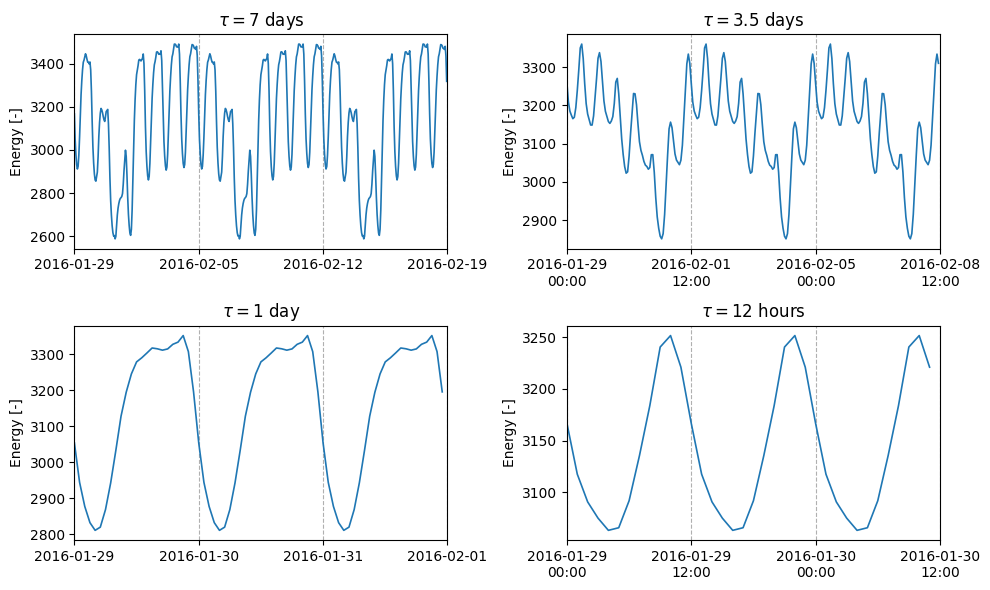

In [9]:

def ciclo_promedio(df, ycol, periodo_h):
    s = df[ycol].dropna()
    t_h = (s.index - s.index[0]).total_seconds()/3600.0
    fase_h = np.rint(t_h % periodo_h).astype(int) % int(periodo_h)
    g = pd.Series(s.values, index=fase_h).groupby(level=0).mean()
    P = int(periodo_h)
    m = g.reindex(range(P)).interpolate(limit_direction="both")
    return m, fase_h  # índice 0..P-1

periodos = [168, 84, 24, 12]
titulos = [r"$\tau = 7$ days", r"$\tau = 3.5$ days",
           r"$\tau = 1$ day", r"$\tau = 12$ hours"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=False)
axes = axes.ravel()

# Ancla para las etiquetas de fecha: primer timestamp de la serie
anchor = data["N_DEMANDA"].dropna().index[0].floor("h")

for ax, P, titulo in zip(axes, periodos, titulos):
    m,fase_h = ciclo_promedio(data, "N_DEMANDA", P)   # 0..P-1
    y3 = np.tile(m.values, 3)
    x3 = np.arange(3*int(P))

    ax.plot(x3, y3, lw=1.2)
    ax.set_xlim(0, 3*int(P))

    # Ticks en 0, τ, 2τ, 3τ  (grid cada τ)
    ticks = [0, int(P), 2*int(P), 3*int(P)]
    ax.set_xticks(ticks)

    # Etiquetas: fecha (y hora si P no es múltiplo de 24 h)
    dticks = [anchor + pd.Timedelta(hours=int(k*P)) for k in range(4)]
    if (P % 24) == 0:
        labels = [d.strftime("%Y-%m-%d") for d in dticks]
    else:
        labels = [d.strftime("%Y-%m-%d\n%H:%M") for d in dticks]

    ax.set_xticklabels(labels)
    ax.grid(axis="x", which="major", linestyle="--")

    ax.set_title(titulo)
    # ax.set_xlabel("Fase (marcada cada τ) · etiquetas = fechas")
    ax.set_ylabel("Energy [-]")
    print(fase_h)
    

fig.tight_layout()
plt.show()


In [10]:

def _fit_harmonic(df, ycol, periodo_h, n_harmonics=1):
    """
    Ajusta un modelo armónico y = a0 + Σ_k [ak*cos(k*ω*t) + bk*sin(k*ω*t)]
    a una serie con índice datetime. Devuelve (beta, t0), donde beta son
    los coeficientes y t0 es el ancla temporal usada para medir t (horas).
    """
    s = df[ycol].dropna()
    if s.empty:
        raise ValueError("Serie vacía tras dropna().")

    t0 = s.index[0]
    t_h = (s.index - t0).total_seconds() / 3600.0
    y   = s.values.astype(float)

    # Matriz de diseño: [1, cos(ωt), sin(ωt), cos(2ωt), sin(2ωt), ...]
    ω = 2.0*np.pi/periodo_h
    cols = [np.ones_like(t_h)]
    for k in range(1, n_harmonics+1):
        cols.append(np.cos(k*ω*t_h))
        cols.append(np.sin(k*ω*t_h))
    X = np.column_stack(cols)

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta, t0

def _predict_harmonic(beta, t_h, periodo_h, n_harmonics=1):
    """Predice en horas relativas t_h usando el mismo orden armónico."""
    ω = 2.0*np.pi/periodo_h
    cols = [np.ones_like(t_h)]
    for k in range(1, n_harmonics+1):
        cols.append(np.cos(k*ω*t_h))
        cols.append(np.sin(k*ω*t_h))
    X = np.column_stack(cols)
    return X @ beta

def plot_ciclo_y_armonico(df, ycol, periodos, titulos, n_harmonics=1):
    """
    Para cada periodo P (h), grafica:
      - el ciclo promedio (tu 'm' repetido 3 veces)
      - el ajuste armónico con el mismo periodo (y opcionalmente más armónicos)
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=False)
    axes = axes.ravel()

    # Ancla para las etiquetas de fecha: primer timestamp de la serie
    s = df[ycol].dropna()
    anchor = s.index[0].floor("h")

    for ax, P, titulo in zip(axes, periodos, titulos):
        # Ciclo promedio por fase (tu función)
        m, _ = ciclo_promedio(df, ycol, P)  # índice 0..P-1
        y3 = np.tile(m.values, 3)
        x3 = np.arange(3*int(P))  # horas relativas 0..3P-1

        # Ajuste armónico con periodo P (puedes subir n_harmonics si deseas)
        beta, t0 = _fit_harmonic(df, ycol, P, n_harmonics=n_harmonics)
        # Para que el eje x coincida (0 en el inicio de la serie):
        # construimos una grilla de 3P horas a partir de t0.
        y_fit = _predict_harmonic(beta, x3.astype(float), P, n_harmonics=n_harmonics)

        # Plots
        ax.plot(x3, y3, lw=1.2, label="Ciclo promedio (3×τ)")
        ax.plot(x3, y_fit, lw=1.4, linestyle="-.", label=f"Armónico (τ={P} h)")

        ax.set_xlim(0, 3*int(P))

        # Ticks en 0, τ, 2τ, 3τ  (grid cada τ)
        ticks = [0, int(P), 2*int(P), 3*int(P)]
        ax.set_xticks(ticks)

        # Etiquetas de fecha (ancladas a 'anchor')
        dticks = [anchor + pd.Timedelta(hours=int(k*P)) for k in range(4)]
        if (P % 24) == 0:
            labels = [d.strftime("%Y-%m-%d") for d in dticks]
        else:
            labels = [d.strftime("%Y-%m-%d\n%H:%M") for d in dticks]
        ax.set_xticklabels(labels)
        ax.grid(axis="x", which="major", linestyle="--")

        ax.set_title(titulo)
        ax.set_ylabel(ycol)
        ax.legend(loc="best")

    fig.tight_layout()
    return fig, axes


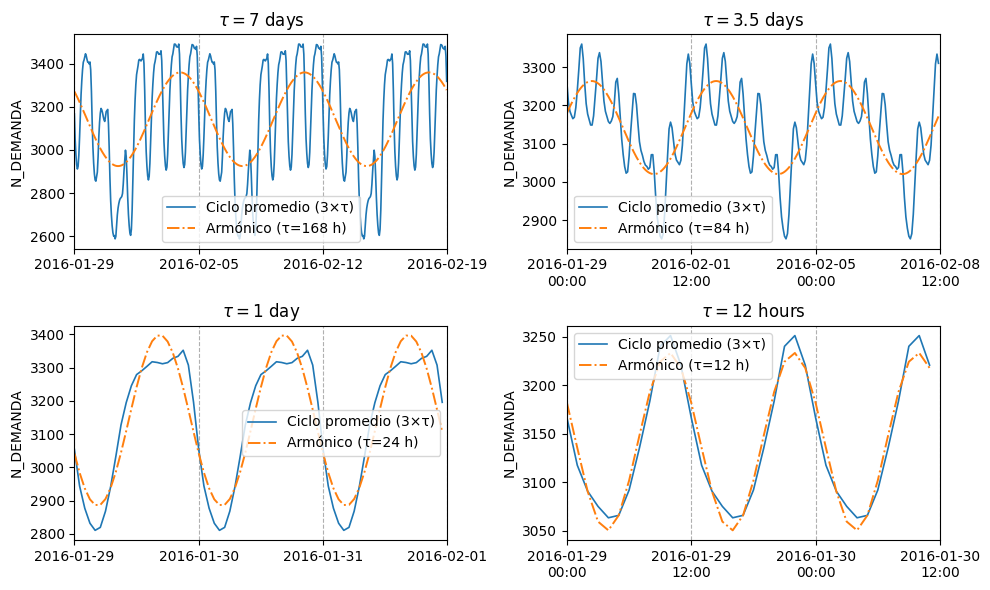

In [11]:
periodos = [168, 84, 24, 12]
titulos = [r"$\tau = 7$ days", r"$\tau = 3.5$ days",
           r"$\tau = 1$ day", r"$\tau = 12$ hours"]

# n_harmonics=1 → sólo la frecuencia fundamental del periodo dado
# Puedes probar n_harmonics=2 para capturar formas no sinusoidales.
fig, axes = plot_ciclo_y_armonico(data, "N_DEMANDA", periodos, titulos, n_harmonics=1)
plt.show()


<Axes: xlabel='index'>

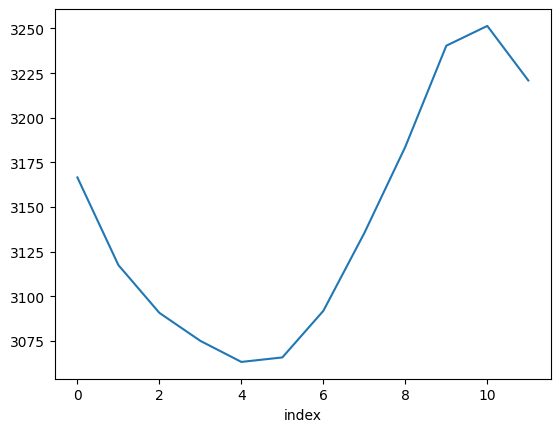

In [12]:
m.plot()